Perbandingan penggunaan aplikasi baca webtoon dan noveltoon di google play store berdasarkan analisis review pengguna.

In [1]:
!pip install google-play-scraper

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 1.8 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import re
import string
from google_play_scraper import reviews, Sort
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import LatentDirichletAllocation
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from collections import Counter

In [3]:
#Scraping data
def scrape_reviews(app_id, app_name, count=5000):
    result, _ = reviews(
        app_id,
        lang='id',
        country='id',
        sort=Sort.MOST_RELEVANT,
        count=count,
        filter_score_with=None
    )
    if not result:
        df = pd.DataFrame(columns=['content', 'score', 'at'])
    else:
        df = pd.DataFrame(result)
        required_cols = ['content', 'score', 'at']
        for col in required_cols:
            if col not in df.columns:
                df[col] = None
        df = df[['content', 'score', 'at']]
        df.rename(columns={'content':'text'}, inplace=True)
        df['app'] = app_name
    return df

df_webtoon = scrape_reviews('com.naver.linewebtoon', 'Webtoon', 5000)
df_noveltoon = scrape_reviews('mobi.mangatoon.novel', 'Noveltoon', 5000)

# Gabungkan dataset
df = pd.concat([df_webtoon, df_noveltoon], ignore_index=True)

In [4]:
import pandas as pd
from google_play_scraper import reviews, Sort

# ================================
# Fungsi Scraping Review
# ================================
def scrape_reviews(app_id, app_name, count=10000):
    result, _ = reviews(
        app_id,
        lang='id',
        country='id',
        sort=Sort.MOST_RELEVANT,
        count=count,
        filter_score_with=None
    )

    if not result:
        df = pd.DataFrame(columns=['ulasan', 'rating', 'at', 'app'])
    else:
        df = pd.DataFrame(result)
        df = df[['content', 'score', 'at']]
        df.rename(columns={
            'content': 'ulasan',
            'score': 'rating'
        }, inplace=True)
        df['app'] = app_name

    return df


# ================================
# Scraping per Aplikasi
# ================================
df_webtoon = scrape_reviews(
    'com.naver.linewebtoon',
    'Webtoon',
    10000
)

df_noveltoon = scrape_reviews(
    'mobi.mangatoon.novel',
    'Noveltoon',
    10000
)

# ================================
# Simpan CSV Terpisah
# ================================
df_webtoon.to_csv(
    'dataset_ulasan_webtoon.csv',
    index=False,
    encoding='utf-8-sig'
)

df_noveltoon.to_csv(
    'dataset_ulasan_noveltoon.csv',
    index=False,
    encoding='utf-8-sig'
)

In [5]:
# Statistik rating
df['score'].describe()

,score
count,10000.000000
mean,3.510700
std,1.557668
min,1.000000
25%,2.000000
50%,4.000000
75%,5.000000
max,5.000000


In [6]:
df['app'].value_counts()

,count
app,
Webtoon,5000
Noveltoon,5000


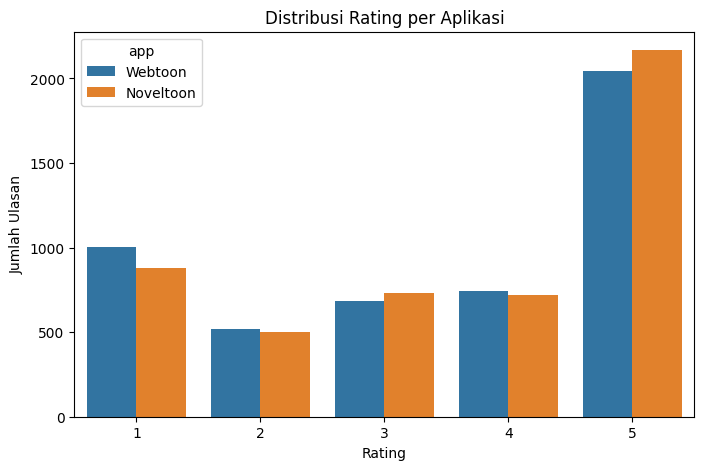

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.countplot(x='score', hue='app', data=df)
plt.title('Distribusi Rating per Aplikasi')
plt.xlabel('Rating')
plt.ylabel('Jumlah Ulasan')
plt.show()

In [8]:
df['ulasan_length'] = df['text'].apply(lambda x: len(str(x).split()))
df.groupby('app')['ulasan_length'].describe()

,count,mean,std,min,25%,50%,75%,max
app,,,,,,,,
Noveltoon,5000.0,33.6994,16.933895,4.0,21.0,29.0,42.0,97.0
Webtoon,5000.0,38.2708,20.979530,2.0,22.0,37.0,51.0,130.0


In [9]:
# Review terpanjang
df.iloc[df['ulasan_length'].idxmax()][['app','text','score']]

# Review terpendek
df.iloc[df['ulasan_length'].idxmin()][['app','text','score']]

,2014
app,Webtoon
text,"bagus!!,grafiknya pass"
score,5


In [10]:
# Total ulasan
total_ulasan = len(df)
print(f"Total ulasan dari kedua APK: {total_ulasan}")

# Jumlah ulasan per aplikasi
total_per_app = df['app'].value_counts()
print("Jumlah ulasan per aplikasi:")
print(total_per_app)

# Total ulasan per rating
total_per_rating = df.groupby(['app','score']).size().reset_index(name='jumlah')
print(total_per_rating)

Total ulasan dari kedua APK: 10000
Jumlah ulasan per aplikasi:
app
Webtoon      5000
Noveltoon    5000
Name: count, dtype: int64
         app  score  jumlah
0  Noveltoon      1     882
1  Noveltoon      2     498
2  Noveltoon      3     732
3  Noveltoon      4     720
4  Noveltoon      5    2168
5    Webtoon      1    1001
6    Webtoon      2     521
7    Webtoon      3     687
8    Webtoon      4     746
9    Webtoon      5    2045


In [11]:
df['ulasan_lower'] = df['text'].str.lower()

In [12]:
import re

def clean_text(text):
    text = str(text)
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)  # hapus non-ASCII / emoji
    text = re.sub(r'\d+', ' ', text)            # hapus angka
    text = re.sub(r'[^\w\s]', ' ', text)        # hapus tanda baca
    return text

df['ulasan_clean'] = df['ulasan_lower'].apply(clean_text)
df.head()

,text,score,at,app,ulasan_length,ulasan_lower,ulasan_clean
0,"aplikasi kapitalis, banyak sekali cara licik k...",3,2026-01-06 09:13:40,Webtoon,42,"aplikasi kapitalis, banyak sekali cara licik k...",aplikasi kapitalis banyak sekali cara licik k...
1,"tolong balikin tampilan Webtoon yg lama dong, ...",2,2025-12-20 15:01:17,Webtoon,56,"tolong balikin tampilan webtoon yg lama dong, ...",tolong balikin tampilan webtoon yg lama dong ...
2,Webtoon kenapa jadi ga ada tanda like dan ga b...,3,2025-12-19 13:12:57,Webtoon,67,webtoon kenapa jadi ga ada tanda like dan ga b...,webtoon kenapa jadi ga ada tanda like dan ga b...
3,"woy lah cikkk, pas udah di update malah jadi g...",2,2026-01-02 07:41:13,Webtoon,52,"woy lah cikkk, pas udah di update malah jadi g...",woy lah cikkk pas udah di update malah jadi g...
4,iklan di tengah-tengah atau setiap selesai 1 e...,2,2025-12-09 10:11:11,Webtoon,41,iklan di tengah-tengah atau setiap selesai 1 e...,iklan di tengah tengah atau setiap selesai e...


In [13]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

stop_words = set(stopwords.words('indonesian'))

def remove_stopwords(text):
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return ' '.join(words)

df['ulasan_stopword'] = df['ulasan_clean'].apply(remove_stopwords)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [14]:
!pip install Sastrawi
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

factory = StemmerFactory()
stemmer = factory.create_stemmer()

def stemming_text(text):
    return stemmer.stem(text)

df['ulasan_stem'] = df['ulasan_stopword'].apply(stemming_text)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 6.1 MB/s eta 0:00:00


In [15]:
df.head()

,text,score,at,app,ulasan_length,ulasan_lower,ulasan_clean,ulasan_stopword,ulasan_stem
0,"aplikasi kapitalis, banyak sekali cara licik k...",3,2026-01-06 09:13:40,Webtoon,42,"aplikasi kapitalis, banyak sekali cara licik k...",aplikasi kapitalis banyak sekali cara licik k...,aplikasi kapitalis licik keuntungan ya iklan g...,aplikasi kapitalis licik untung ya iklan grati...
1,"tolong balikin tampilan Webtoon yg lama dong, ...",2,2025-12-20 15:01:17,Webtoon,56,"tolong balikin tampilan webtoon yg lama dong, ...",tolong balikin tampilan webtoon yg lama dong ...,tolong balikin tampilan webtoon yg yg menurutk...,tolong balikin tampil webtoon yg yg turut aneh...
2,Webtoon kenapa jadi ga ada tanda like dan ga b...,3,2025-12-19 13:12:57,Webtoon,67,webtoon kenapa jadi ga ada tanda like dan ga b...,webtoon kenapa jadi ga ada tanda like dan ga b...,webtoon ga tanda like ga capture screen lagiii...,webtoon ga tanda like ga capture screen lagiii...
3,"woy lah cikkk, pas udah di update malah jadi g...",2,2026-01-02 07:41:13,Webtoon,52,"woy lah cikkk, pas udah di update malah jadi g...",woy lah cikkk pas udah di update malah jadi g...,woy cikkk pas udah update gak baca looksim uda...,woy cikkk pas udah update gak baca looksim uda...
4,iklan di tengah-tengah atau setiap selesai 1 e...,2,2025-12-09 10:11:11,Webtoon,41,iklan di tengah-tengah atau setiap selesai 1 e...,iklan di tengah tengah atau setiap selesai e...,iklan selesai episode langsung ngarahin aplika...,iklan selesai episode langsung ngarahin aplika...


/tmp/ipython-input-180811272.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sentimen_count.index, y=sentimen_count.values, palette='viridis')


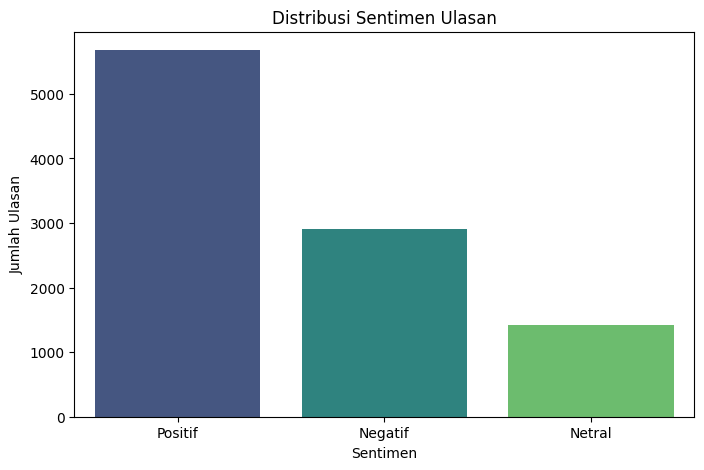

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Tambahkan kolom sentimen berdasarkan rating
def get_sentiment(score):
    if score >= 4:
        return 'Positif'
    elif score == 3:
        return 'Netral'
    else:
        return 'Negatif'

df['sentimen'] = df['score'].apply(get_sentiment)

sentimen_count = df['sentimen'].value_counts()

plt.figure(figsize=(8,5))
sns.barplot(x=sentimen_count.index, y=sentimen_count.values, palette='viridis')
plt.title('Distribusi Sentimen Ulasan')
plt.xlabel('Sentimen')
plt.ylabel('Jumlah Ulasan')
plt.show()

In [17]:
# ================================
# Fungsi Pelabelan Sentimen
# ================================
def label_sentiment(rating):
    if rating <= 2:
        return 'Negatif'
    elif rating == 3:
        return 'Netral'
    else:
        return 'Positif'


# ================================
# Terapkan ke DataFrame
# ================================
df_webtoon['sentimen'] = df_webtoon['rating'].apply(label_sentiment)
df_noveltoon['sentimen'] = df_noveltoon['rating'].apply(label_sentiment)


# ================================
# Cek Distribusi Sentimen
# ================================
print("Distribusi Sentimen Webtoon:")
print(df_webtoon['sentimen'].value_counts())

print("\nDistribusi Sentimen Noveltoon:")
print(df_noveltoon['sentimen'].value_counts())

Distribusi Sentimen Webtoon:
sentimen
Positif    5720
Negatif    2982
Netral     1298
Name: count, dtype: int64

Distribusi Sentimen Noveltoon:
sentimen
Positif    6396
Negatif    2388
Netral     1216
Name: count, dtype: int64


In [18]:
# ================================
# IMPORT LIBRARY
# ================================
import pandas as pd
from IPython.display import HTML, display

# ================================
# CONTOH DATA (GANTI DENGAN DATA KAMU)
# ================================
df_webtoon = pd.DataFrame({
    "rating": [1,2,3,4,5,5,4,3,2,1,4,5,3,2]
})

# ================================
# FUNGSI LABEL SENTIMEN
# ================================
def label_sentiment(rating):
    if rating <= 2:
        return 'Negatif'
    elif rating == 3:
        return 'Netral'
    else:
        return 'Positif'

df_webtoon['sentimen'] = df_webtoon['rating'].apply(label_sentiment)

# ================================
# HITUNG DISTRIBUSI SENTIMEN
# ================================
counts = df_webtoon['sentimen'].value_counts()

negatif = counts.get('Negatif', 0)
netral  = counts.get('Netral', 0)
positif = counts.get('Positif', 0)

# ================================
# TAMPILAN HTML + CSS (CARD)
# ================================
html = f"""
<style>
.container {{
    display: flex;
    justify-content: space-around;
    gap: 20px;
    font-family: Arial, sans-serif;
}}

.card {{
    width: 300px;
    background: white;
    border-radius: 18px;
    padding: 30px;
    text-align: center;
    box-shadow: 0 6px 16px rgba(0,0,0,0.15);
}}

.negatif {{ border-top: 6px solid #e91e63; }}
.netral  {{ border-top: 6px solid #ff9800; }}
.positif {{ border-top: 6px solid #2196f3; }}

.icon {{
    font-size: 48px;
}}

.title {{
    font-size: 22px;
    font-weight: bold;
    margin: 15px 0;
}}

.star {{
    font-size: 22px;
    color: gold;
}}

.desc {{
    color: gray;
    margin-top: 8px;
    font-size: 14px;
}}

.count {{
    font-size: 32px;
    font-weight: bold;
    margin-top: 15px;
}}
</style>

<div class="container">

    <div class="card negatif">
        <div class="icon">👎</div>
        <div class="title" style="color:#e91e63">SENTIMEN NEGATIF</div>
        <div class="star">⭐ ⭐ ☆ ☆ ☆</div>
        <div class="desc">Rating Bintang 1 & 2</div>
        <div class="count">{negatif}</div>
    </div>

    <div class="card netral">
        <div class="icon">⚖️</div>
        <div class="title" style="color:#ff9800">SENTIMEN NETRAL</div>
        <div class="star">⭐ ⭐ ⭐ ☆ ☆</div>
        <div class="desc">Rating Bintang 3</div>
        <div class="count">{netral}</div>
    </div>

    <div class="card positif">
        <div class="icon">👍</div>
        <div class="title" style="color:#2196f3">SENTIMEN POSITIF</div>
        <div class="star">⭐ ⭐ ⭐ ⭐ ⭐</div>
        <div class="desc">Rating Bintang 4 & 5</div>
        <div class="count">{positif}</div>
    </div>

</div>
"""

display(HTML(html))


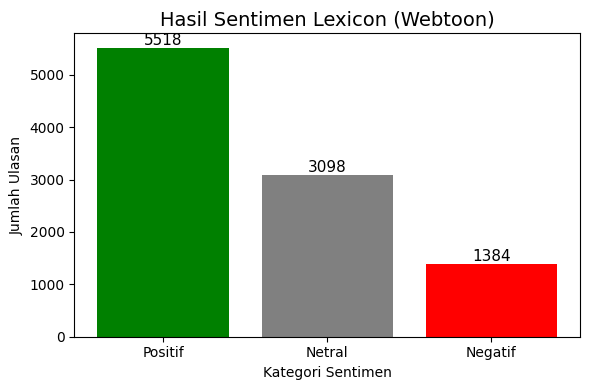

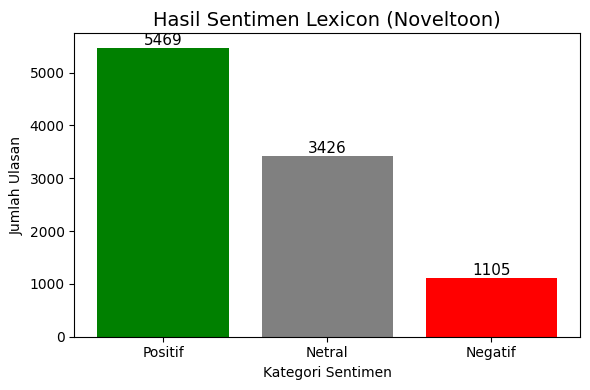

In [20]:
import matplotlib.pyplot as plt
import pandas as pd # Import pandas if not already globally available

# ==========================================================================
# Ensure df_webtoon and df_noveltoon are correctly loaded and processed
# This part is added to resolve KeyError: 'sentimen_lexicon'
# ==========================================================================

try:
    df_webtoon = pd.read_csv('dataset_ulasan_webtoon.csv')
    df_noveltoon = pd.read_csv('dataset_ulasan_noveltoon.csv')
except FileNotFoundError:
    print("Error: CSV files not found. Please ensure they are generated by previous cells.")
    # If files are not found, you might want to handle this gracefully,
    # e.g., by creating dummy data or exiting.
    exit()

# Define lexicon-based sentiment analysis words
positive_words = [
    'bagus', 'baik', 'mantap', 'keren', 'suka', 'puas',
    'menarik', 'recommended', 'hebat', 'seru', 'love', 'terbaik'
]

negative_words = [
    'buruk', 'jelek', 'kecewa', 'lemot', 'error', 'bug',
    'crash', 'parah', 'benci', 'payah', 'lag'
]

def label_sentiment_lexicon(text):
    text = str(text).lower()
    score = 0

    for word in positive_words:
        if word in text:
            score += 1

    for word in negative_words:
        if word in text:
            score -= 1

    if score > 0:
        return 'Positif'
    elif score < 0:
        return 'Negatif'
    else:
        return 'Netral'

# Apply the sentiment labeling to create the 'sentimen_lexicon' column
df_webtoon['sentimen_lexicon'] = df_webtoon['ulasan'].apply(label_sentiment_lexicon)
df_noveltoon['sentimen_lexicon'] = df_noveltoon['ulasan'].apply(label_sentiment_lexicon)

# ================================
# 6. BAR CHART PER SENTIMEN LEXICON
# ================================
def plot_sentiment_lexicon(df, app_name):
    # Hitung jumlah masing-masing sentimen
    sentiment_counts = df['sentimen_lexicon'].value_counts()

    # Pastikan urutan: Positif, Netral, Negatif
    order = ['Positif', 'Netral', 'Negatif']
    values = [sentiment_counts.get(s, 0) for s in order]

    # Warna bar
    colors = ['green', 'gray', 'red']

    plt.figure(figsize=(6,4))
    bars = plt.bar(order, values, color=colors)

    plt.title(f'Hasil Sentimen Lexicon ({app_name})', fontsize=14)
    plt.xlabel('Kategori Sentimen')
    plt.ylabel('Jumlah Ulasan')

    # Tambahkan label angka di atas bar
    for bar, value in zip(bars, values):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            str(value),
            ha='center',
            va='bottom',
            fontsize=11
        )

    plt.tight_layout()
    plt.show()


# ================================
# Panggil Fungsi untuk Masing-masing Aplikasi
# ================================
plot_sentiment_lexicon(df_webtoon, 'Webtoon')
plot_sentiment_lexicon(df_noveltoon, 'Noveltoon')


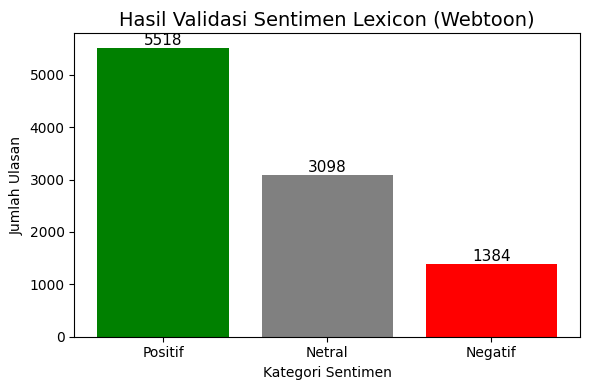

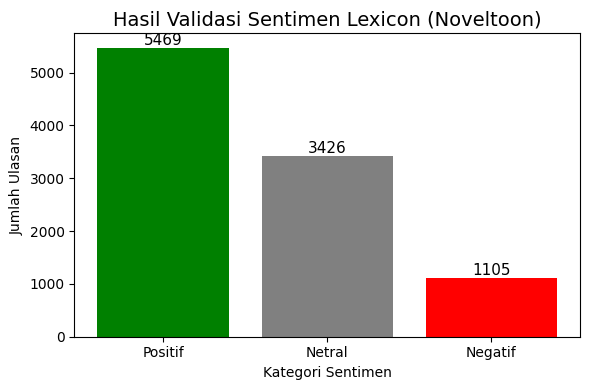

In [21]:
import matplotlib.pyplot as plt

# ================================
# Fungsi Bar Chart Hasil Validasi Lexicon
# ================================
def plot_lexicon_sentiment(df, app_name):
    sentiment_counts = df['sentimen_lexicon'].value_counts()

    plt.figure(figsize=(6,4))
    bars = plt.bar(sentiment_counts.index, sentiment_counts.values, color=['green', 'gray', 'red'])

    plt.title(f'Hasil Validasi Sentimen Lexicon ({app_name})', fontsize=14)
    plt.xlabel('Kategori Sentimen')
    plt.ylabel('Jumlah Ulasan')

    # Tambahkan label angka di atas bar
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f'{int(height)}',
            ha='center',
            va='bottom',
            fontsize=11
        )

    plt.tight_layout()
    plt.show()


# ================================
# Panggil Fungsi untuk Masing-masing Aplikasi
# ================================
plot_lexicon_sentiment(df_webtoon, 'Webtoon')
plot_lexicon_sentiment(df_noveltoon, 'Noveltoon')


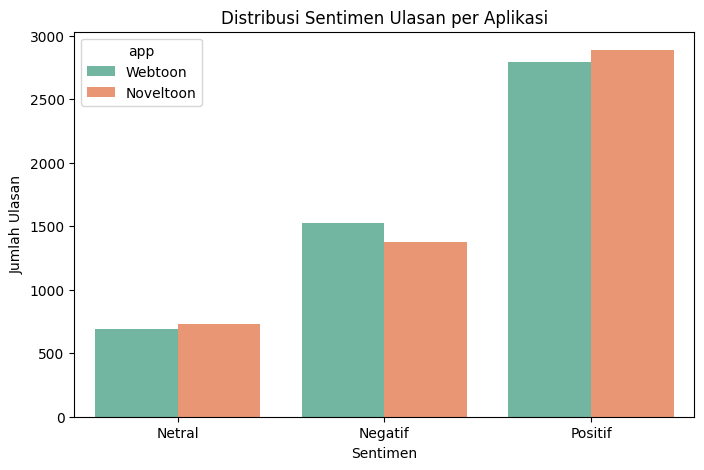

In [23]:
plt.figure(figsize=(8,5))
sns.countplot(x='sentimen', hue='app', data=df, palette='Set2')
plt.title('Distribusi Sentimen Ulasan per Aplikasi')
plt.xlabel('Sentimen')
plt.ylabel('Jumlah Ulasan')
plt.show()

In [24]:
# Ambil sampel 20 ulasan dari setiap label
sample_df = df.groupby('sentimen').sample(20, random_state=42)
sample_df[['text', 'score', 'sentimen']]

,text,score,sentimen
471,Aplikasinya di banyak nge klik otomatis tolong...,1,Negatif
2795,Ini Webtoon Knp ya?? Kok nggak bisa di pakai.....,1,Negatif
1707,Hari ini baru coba buka aplikasi webtoon setel...,1,Negatif
5535,Bagus si. Cuma sistem poin ini mengganggu seka...,1,Negatif
3978,maaf untuk kali ini aku kasih bintang satu min...,1,Negatif
8679,Saya perbarui kok jadi tambah jelek. Punya say...,2,Negatif
3770,Kenapa yah Webtoon jadi seperti ini??dulu aku ...,1,Negatif
9609,"Tidak dapat mengambil data, padahal wifi or da...",1,Negatif
5682,Untuk developer tolong kembangkan fitur import...,1,Negatif
2327,"saya membeli koin webtoon sekarang susah, mana...",1,Negatif


In [25]:
positif_words = ['bagus', 'mantap', 'hebat', 'suka', 'recommended']
negatif_words = ['buruk', 'jelek', 'tidak', 'mengecewakan', 'parah']

def validate_label(row):
    text = row['text'].lower()
    label = row['sentimen']

    if label == 'Positif' and any(word in text for word in negatif_words):
        return 'Perlu Dicek'
    if label == 'Negatif' and any(word in text for word in positif_words):
        return 'Perlu Dicek'
    return 'Valid'

df['label_validasi'] = df.apply(validate_label, axis=1)

In [26]:
df['label_validasi'].value_counts()

,count
label_validasi,
Valid,8209
Perlu Dicek,1791


In [27]:
validasi_count = df['label_validasi'].value_counts()
print(validasi_count)

label_validasi
Valid          8209
Perlu Dicek    1791
Name: count, dtype: int64


/tmp/ipython-input-3038145240.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=validasi_count.index, y=validasi_count.values, palette='Set1')


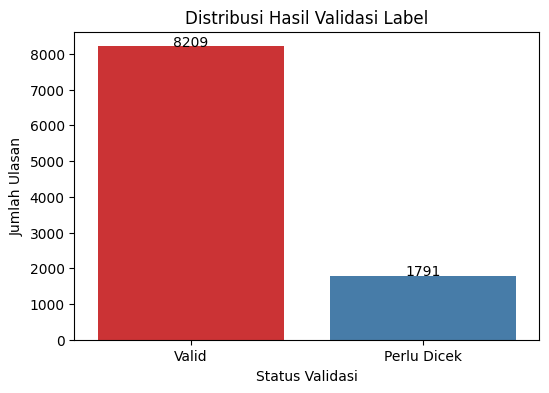

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.barplot(x=validasi_count.index, y=validasi_count.values, palette='Set1')
plt.title('Distribusi Hasil Validasi Label')
plt.xlabel('Status Validasi')
plt.ylabel('Jumlah Ulasan')

# Menambahkan angka di atas bar
for i, v in enumerate(validasi_count.values):
    plt.text(i, v + 10, str(v), ha='center')

plt.show()

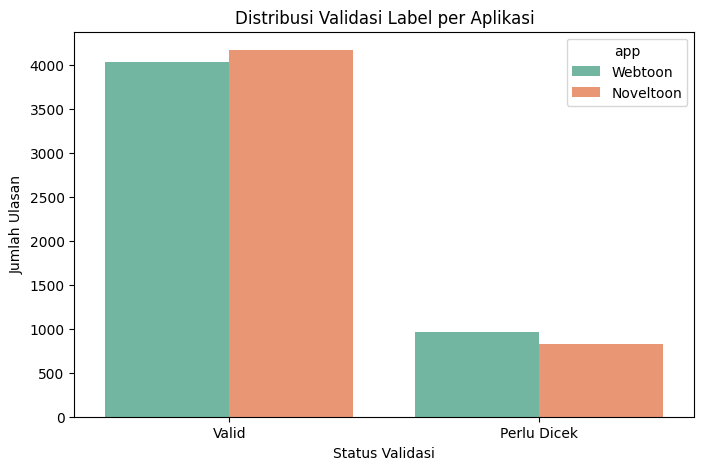

In [29]:
plt.figure(figsize=(8,5))
sns.countplot(x='label_validasi', hue='app', data=df, palette='Set2')
plt.title('Distribusi Validasi Label per Aplikasi')
plt.xlabel('Status Validasi')
plt.ylabel('Jumlah Ulasan')
plt.show()

In [30]:
!pip install wordcloud matplotlib
from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [31]:
def plot_wordcloud(data, title):
    text = ' '.join(data.dropna())
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=16)
    plt.show()

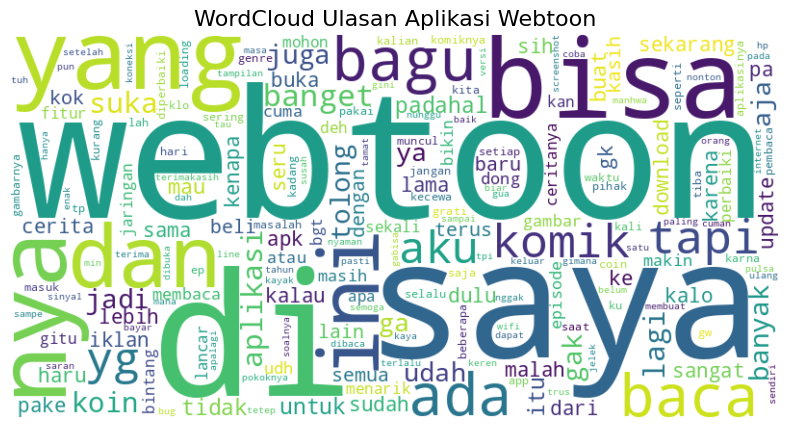

In [32]:
!pip install google-play-scraper

from wordcloud import WordCloud
import matplotlib.pyplot as plt
import pandas as pd
from google_play_scraper import reviews, Sort

# Re-defining scrape_reviews function to ensure df_webtoon is properly created
# This definition is consistent with cell bfwE1aODckzt's approach to column naming
def scrape_reviews(app_id, app_name, count=10000):
    result, _ = reviews(
        app_id,
        lang='id',
        country='id',
        sort=Sort.MOST_RELEVANT,
        count=count,
        filter_score_with=None
    )

    if not result:
        df_temp = pd.DataFrame(columns=['ulasan', 'rating', 'at', 'app'])
    else:
        df_temp = pd.DataFrame(result)
        # Select and rename columns as per notebook's convention
        df_temp = df_temp[['content', 'score', 'at']]
        df_temp.rename(columns={
            'content': 'ulasan',
            'score': 'rating'
        }, inplace=True)
        df_temp['app'] = app_name

    return df_temp

def plot_wordcloud_webtoon(df):
    # Changed 'content' to 'ulasan' to match the column name produced by the scrape_reviews function
    text = ' '.join(df['ulasan'].dropna())

    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        max_words=200,
        collocations=False
    ).generate(text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title('WordCloud Ulasan Aplikasi Webtoon', fontsize=16)
    plt.show()

# Call scrape_reviews to define df_webtoon within this cell's scope
df_webtoon = scrape_reviews('com.naver.linewebtoon', 'Webtoon', 10000)

# panggil fungsi
plot_wordcloud_webtoon(df_webtoon)

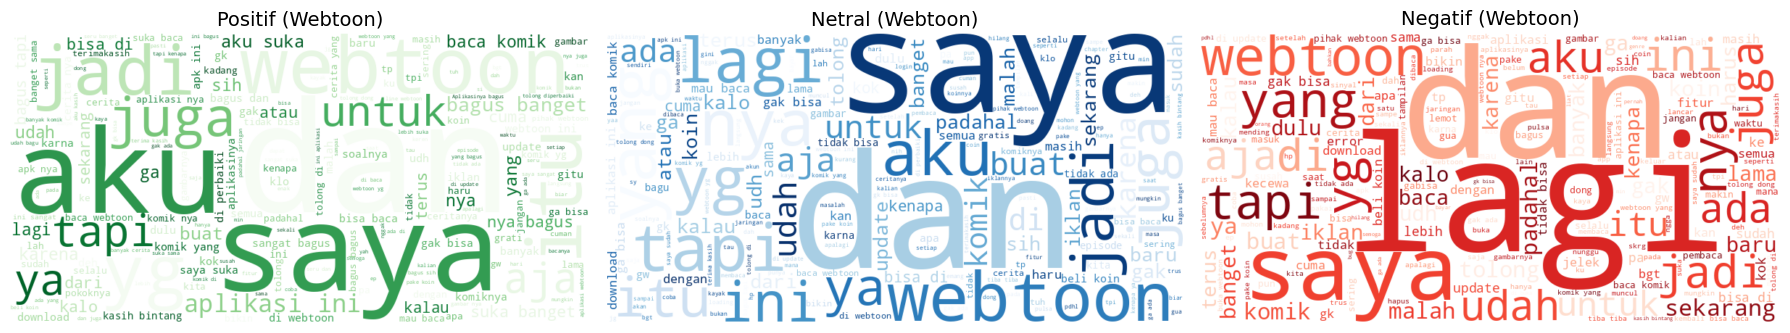

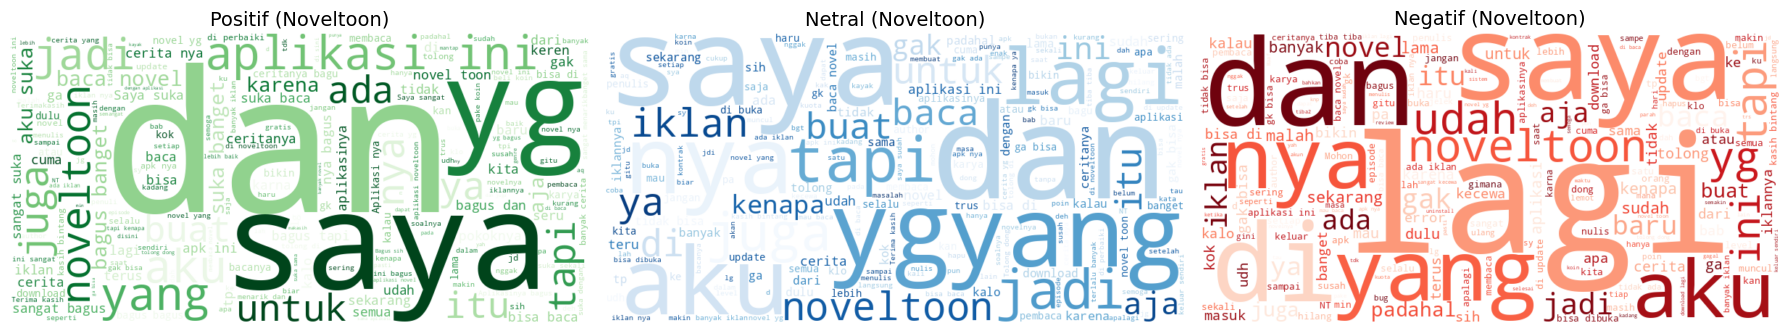

In [33]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
import pandas as pd

# --- Ensure df_webtoon and df_noveltoon are correctly loaded and processed ---
# Load dataframes from CSV to ensure 'ulasan' column is present
try:
    df_webtoon = pd.read_csv('dataset_ulasan_webtoon.csv')
    df_noveltoon = pd.read_csv('dataset_ulasan_noveltoon.csv')
except FileNotFoundError:
    print("Error: CSV files not found. Please ensure they are generated by previous cells.")
    # Exit or handle the error appropriately if files are missing
    exit()

# Define lexicon-based sentiment analysis functions (copied from NzH7Ui3Yqyx3 to ensure robustness)
positive_words = [
    'bagus', 'baik', 'mantap', 'keren', 'suka', 'puas',
    'menarik', 'recommended', 'hebat', 'seru', 'love', 'terbaik'
]

negative_words = [
    'buruk', 'jelek', 'kecewa', 'lemot', 'error', 'bug',
    'crash', 'parah', 'benci', 'payah', 'lag'
]

def label_sentiment_lexicon(text):
    text = str(text).lower()
    score = 0

    for word in positive_words:
        if word in text:
            score += 1

    for word in negative_words:
        if word in text:
            score -= 1

    if score > 0:
        return 'Positif'
    elif score < 0:
        return 'Negatif'
    else:
        return 'Netral'

df_webtoon['sentimen_lexicon'] = df_webtoon['ulasan'].apply(label_sentiment_lexicon)
df_noveltoon['sentimen_lexicon'] = df_noveltoon['ulasan'].apply(label_sentiment_lexicon)

# ================================
# Fungsi Membuat WordCloud per Sentimen
# ================================
def plot_wordcloud_sentiment(df, app_name):
    sentiments = ['Positif', 'Netral', 'Negatif']
    # Changed single color names to valid colormap names
    colors = {'Positif':'Greens', 'Netral':'Blues', 'Negatif':'Reds'}

    plt.figure(figsize=(18,5))

    for i, sentiment in enumerate(sentiments, 1):
        # Gabungkan semua ulasan untuk sentiment tertentu
        text = ' '.join(df[df['sentimen_lexicon'] == sentiment]['ulasan'].dropna().astype(str))

        # Buat WordCloud
        wordcloud = WordCloud(
            width=800,
            height=400,
            background_color='white',
            stopwords=STOPWORDS,
            colormap=colors[sentiment]
        ).generate(text)

        # Plot
        plt.subplot(1, 3, i)
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.axis('off')
        plt.title(f'{sentiment} ({app_name})', fontsize=14)

    plt.tight_layout()
    plt.show()


# ================================
# Panggil Fungsi untuk Masing-masing Aplikasi
# ================================
plot_wordcloud_sentiment(df_webtoon, 'Webtoon')
plot_wordcloud_sentiment(df_noveltoon, 'Noveltoon')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


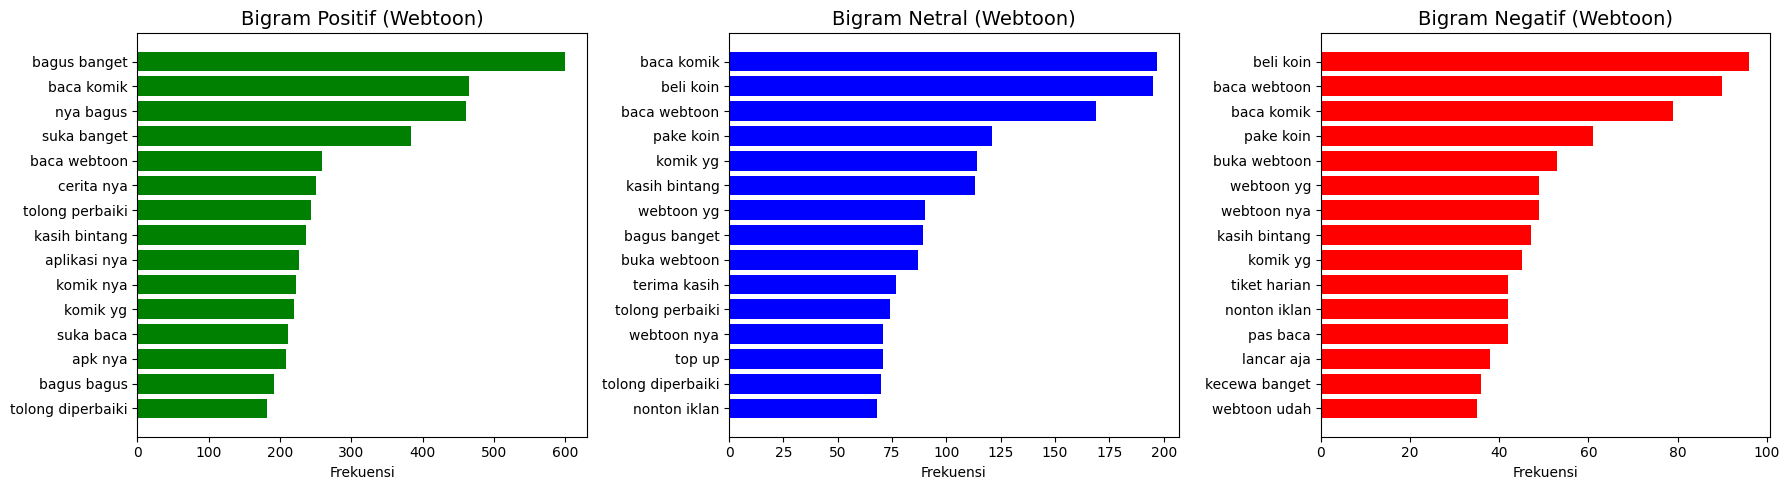

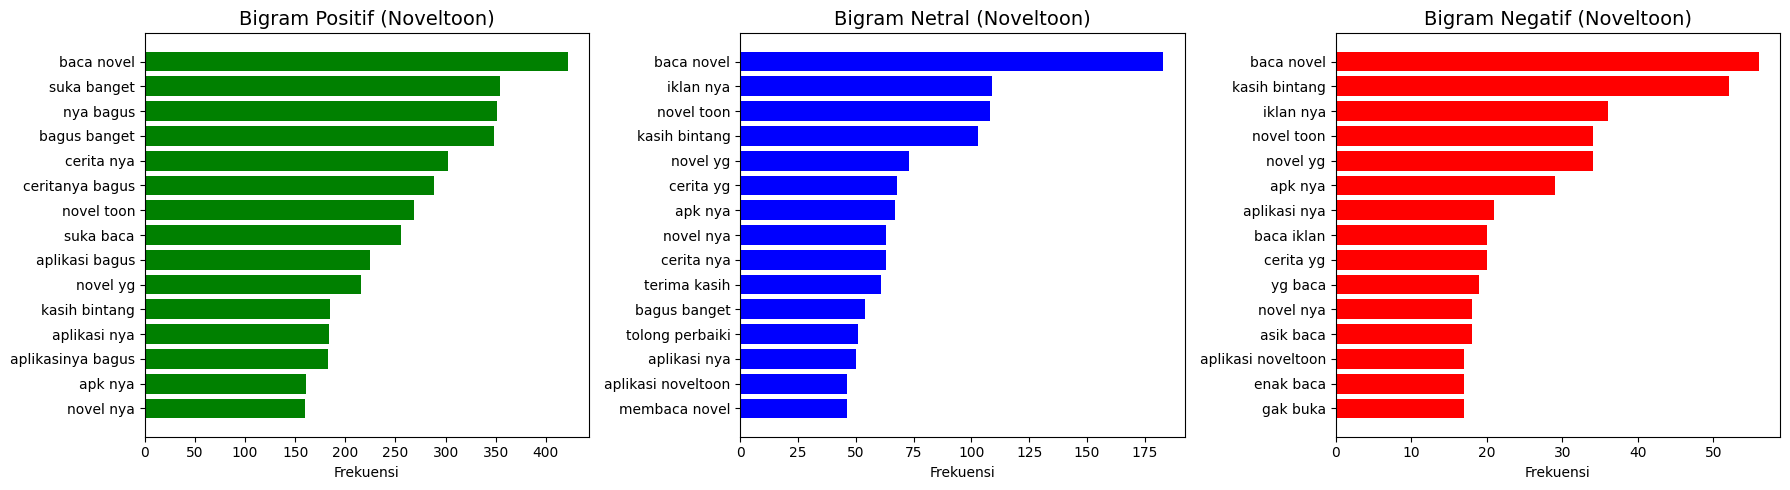

In [34]:
import matplotlib.pyplot as plt
from collections import Counter
import nltk
from nltk.util import ngrams
from nltk.corpus import stopwords
import re

nltk.download('stopwords')
stop_words = set(stopwords.words('indonesian'))

# ================================
# Fungsi Preprocessing Teks
# ================================
def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)  # hapus angka & tanda baca
    tokens = [word for word in text.split() if word not in stop_words]
    return tokens

# ================================
# Fungsi Bigram dan Plot Bar Chart
# ================================
def plot_bigram_sentiment(df, app_name, top_n=15):
    sentiments = ['Positif', 'Netral', 'Negatif']
    colors = {'Positif':'green', 'Netral':'blue', 'Negatif':'red'}

    plt.figure(figsize=(18,5))

    for i, sentiment in enumerate(sentiments, 1):
        # Ambil teks ulasan per sentimen
        texts = df[df['sentimen_lexicon']==sentiment]['ulasan'].dropna().astype(str)
        tokens_all = []

        for text in texts:
            tokens_all.extend(preprocess_text(text))

        # Buat bigram
        bigram_list = list(ngrams(tokens_all, 2))
        bigram_counts = Counter(bigram_list).most_common(top_n)

        # Siapkan data untuk plot
        bigrams_str = [' '.join(b) for b, _ in bigram_counts]
        counts = [c for _, c in bigram_counts]

        # Plot
        plt.subplot(1, 3, i)
        plt.barh(bigrams_str[::-1], counts[::-1], color=colors[sentiment])
        plt.title(f'Bigram {sentiment} ({app_name})', fontsize=14)
        plt.xlabel('Frekuensi')
        plt.tight_layout()

    plt.show()

# ================================
# Panggil Fungsi untuk Masing-masing Aplikasi
# ================================
plot_bigram_sentiment(df_webtoon, 'Webtoon')
plot_bigram_sentiment(df_noveltoon, 'Noveltoon')


Link Tugas Video

https://drive.google.com/file/d/1aMfyUhqZGks7ffGi3sKHoqriRjt8ZuO3/view?usp=drive_link